In [45]:
#Instalando bibliotecas necessárias para o projeto
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn
#!pip install openpyxl


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
#importar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
#carregar os datasets
try:
    df_leitos = pd.read_excel('leitos.xlsx')
    df_pacientes = pd.read_excel('pacientes.xlsx')
    df_movimentacao = pd.read_csv('eventos_movimentacao.csv', sep=';', engine='python')
except FileNotFoundError:
    print('Confirme que os arquivos estejam no diretório')
    exit()

In [48]:
#conferindo os dados importados
print(df_leitos)
print(df_movimentacao)
print(df_pacientes)

   Leito       Local categoria situacaoleito datainicio      dtfim  \
0   L001   Pediatria  Infantil       Ocupado 2025-07-18 2025-07-28   
1   L002  Enfermaria    Adulto         Livre        NaT        NaT   
2   L003         UTI  Infantil       Limpeza        NaT        NaT   
3   L004  Enfermaria  Infantil       Ocupado 2025-07-05 2025-07-11   
4   L005   Pediatria  Infantil    Manutenção        NaT        NaT   
..   ...         ...       ...           ...        ...        ...   
95  L096         UTI  Infantil       Ocupado 2025-07-21 2025-07-26   
96  L097   Pediatria  Infantil       Ocupado 2025-07-20 2025-07-29   
97  L098  Enfermaria  Infantil       Ocupado 2025-07-15 2025-07-21   
98  L099         UTI    Adulto         Livre        NaT        NaT   
99  L100         UTI  Infantil         Livre        NaT        NaT   

   Cod_Paciente  
0         P0028  
1           NaN  
2           NaN  
3         P0156  
4           NaN  
..          ...  
95        P0084  
96        P0145

In [49]:
df_leitos

,Leito,Local,categoria,situacaoleito,datainicio,dtfim,Cod_Paciente
0,L001,Pediatria,Infantil,Ocupado,2025-07-18,2025-07-28,P0028
1,L002,Enfermaria,Adulto,Livre,NaT,NaT,NaN
2,L003,UTI,Infantil,Limpeza,NaT,NaT,NaN
3,L004,Enfermaria,Infantil,Ocupado,2025-07-05,2025-07-11,P0156
4,L005,Pediatria,Infantil,Manutenção,NaT,NaT,NaN
...,...,...,...,...,...,...,...
95,L096,UTI,Infantil,Ocupado,2025-07-21,2025-07-26,P0084
96,L097,Pediatria,Infantil,Ocupado,2025-07-20,2025-07-29,P0145
97,L098,Enfermaria,Infantil,Ocupado,2025-07-15,2025-07-21,P0180
98,L099,UTI,Adulto,Livre,NaT,NaT,NaN


In [50]:
#tratando o nome das colunas da df_leitos
df_leitos.columns = ['ID_Leito', 'Setor', 'Tipo_Leito', 'Status', 'Data_Ocupacao', 'Data_Liberacao', 'Cod_Paciente']
df_leitos

,ID_Leito,Setor,Tipo_Leito,Status,Data_Ocupacao,Data_Liberacao,Cod_Paciente
0,L001,Pediatria,Infantil,Ocupado,2025-07-18,2025-07-28,P0028
1,L002,Enfermaria,Adulto,Livre,NaT,NaT,NaN
2,L003,UTI,Infantil,Limpeza,NaT,NaT,NaN
3,L004,Enfermaria,Infantil,Ocupado,2025-07-05,2025-07-11,P0156
4,L005,Pediatria,Infantil,Manutenção,NaT,NaT,NaN
...,...,...,...,...,...,...,...
95,L096,UTI,Infantil,Ocupado,2025-07-21,2025-07-26,P0084
96,L097,Pediatria,Infantil,Ocupado,2025-07-20,2025-07-29,P0145
97,L098,Enfermaria,Infantil,Ocupado,2025-07-15,2025-07-21,P0180
98,L099,UTI,Adulto,Livre,NaT,NaT,NaN


In [51]:
#analisando dados de leito
leitos_por_status = df_leitos['Status'].value_counts()
leitos_por_setor = df_leitos['Setor'].value_counts()
print(f'{leitos_por_status} \n ***** \n{leitos_por_setor}')

Status
Ocupado       61
Livre         23
Manutenção    11
Limpeza        5
Name: count, dtype: int64 
 ***** 
Setor
Enfermaria     32
UTI            26
Pediatria      23
Maternidade    19
Name: count, dtype: int64


In [52]:
#conferindo os dados do df_leitos
df_leitos.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Leito        100 non-null    str           
 1   Setor           100 non-null    str           
 2   Tipo_Leito      100 non-null    str           
 3   Status          100 non-null    str           
 4   Data_Ocupacao   61 non-null     datetime64[us]
 5   Data_Liberacao  61 non-null     datetime64[us]
 6   Cod_Paciente    61 non-null     str           
dtypes: datetime64[us](2), str(5)
memory usage: 5.6 KB


In [53]:
#convertendo colunas de data para o tipo datetime
df_leitos['Data_Liberacao'] = pd.to_datetime(df_leitos['Data_Liberacao'], errors = 'coerce')
df_leitos['Data_Ocupacao'] = pd.to_datetime(df_leitos['Data_Ocupacao'], errors = 'coerce')

#conferindo o tipo dos campos de data após a conversão
print(df_leitos[['Data_Liberacao', 'Data_Ocupacao']].dtypes)

print(df_leitos)

#os campos em branco das colunas de data são preenchidos com NaT e não NaN

Data_Liberacao    datetime64[us]
Data_Ocupacao     datetime64[us]
dtype: object
   ID_Leito       Setor Tipo_Leito      Status Data_Ocupacao Data_Liberacao  \
0      L001   Pediatria   Infantil     Ocupado    2025-07-18     2025-07-28   
1      L002  Enfermaria     Adulto       Livre           NaT            NaT   
2      L003         UTI   Infantil     Limpeza           NaT            NaT   
3      L004  Enfermaria   Infantil     Ocupado    2025-07-05     2025-07-11   
4      L005   Pediatria   Infantil  Manutenção           NaT            NaT   
..      ...         ...        ...         ...           ...            ...   
95     L096         UTI   Infantil     Ocupado    2025-07-21     2025-07-26   
96     L097   Pediatria   Infantil     Ocupado    2025-07-20     2025-07-29   
97     L098  Enfermaria   Infantil     Ocupado    2025-07-15     2025-07-21   
98     L099         UTI     Adulto       Livre           NaT            NaT   
99     L100         UTI   Infantil       Livre     

In [54]:
#preenchendo NaN na coluna Cod_Paciente com 'Sem paciente'
df_leitos['Cod_Paciente'] = df_leitos['Cod_Paciente'].fillna('Sem paciente')
print(df_leitos)

   ID_Leito       Setor Tipo_Leito      Status Data_Ocupacao Data_Liberacao  \
0      L001   Pediatria   Infantil     Ocupado    2025-07-18     2025-07-28   
1      L002  Enfermaria     Adulto       Livre           NaT            NaT   
2      L003         UTI   Infantil     Limpeza           NaT            NaT   
3      L004  Enfermaria   Infantil     Ocupado    2025-07-05     2025-07-11   
4      L005   Pediatria   Infantil  Manutenção           NaT            NaT   
..      ...         ...        ...         ...           ...            ...   
95     L096         UTI   Infantil     Ocupado    2025-07-21     2025-07-26   
96     L097   Pediatria   Infantil     Ocupado    2025-07-20     2025-07-29   
97     L098  Enfermaria   Infantil     Ocupado    2025-07-15     2025-07-21   
98     L099         UTI     Adulto       Livre           NaT            NaT   
99     L100         UTI   Infantil       Livre           NaT            NaT   

    Cod_Paciente  
0          P0028  
1   Sem pacie

In [57]:
#Tratando colunas do df_pacientes
df_pacientes.columns = ['ID_Paciente', 'Idade', 'Sexo', 'Faixa_Etaria', 'Tipo_Internacao']
print(df_pacientes)

    ID_Paciente  Idade Sexo Faixa_Etaria Tipo_Internacao
0         P0001      4    M      Criança             UTI
1         P0002     65    M       Adulto       Cirúrgica
2         P0003     42    F       Adulto         Clínica
3         P0004     10    M       Adulto       Cirúrgica
4         P0005      2    M      Criança       Cirúrgica
..          ...    ...  ...          ...             ...
195       P0196     14    F      Criança         Clínica
196       P0197     76    F       Adulto       Cirúrgica
197       P0198     75    F       Adulto         Clínica
198       P0199     30    F       Adulto         Clínica
199       P0200     23    M       Adulto             UTI

[200 rows x 5 columns]


In [ ]:
#Criar uma nova coluna para ajustar a faixa etária conforme outro critério
df_pacientes['Classificao_Idade'] = ''

df_pacientes.loc[df_pacientes['Idade'] <= 17, 'Classificao_Idade'] = 'Menor de idade'
df_pacientes.loc[(df_pacientes['Idade'] >= 18) & (df_pacientes['Idade'] <= 59), 'Classificao_Idade'] = 'Adulto'
df_pacientes.loc[df_pacientes['Idade'] >= 60, 'Classificao_Idade'] = 'Melhor idade'

print(df_pacientes)

    ID_Paciente  Idade Sexo Faixa_Etaria Tipo_Internacao Classificao_Idade
0         P0001      4    M      Criança             UTI    Menor de idade
1         P0002     65    M       Adulto       Cirúrgica      Melhor idade
2         P0003     42    F       Adulto         Clínica            Adulto
3         P0004     10    M       Adulto       Cirúrgica    Menor de idade
4         P0005      2    M      Criança       Cirúrgica    Menor de idade
..          ...    ...  ...          ...             ...               ...
195       P0196     14    F      Criança         Clínica    Menor de idade
196       P0197     76    F       Adulto       Cirúrgica      Melhor idade
197       P0198     75    F       Adulto         Clínica      Melhor idade
198       P0199     30    F       Adulto         Clínica            Adulto
199       P0200     23    M       Adulto             UTI            Adulto

[200 rows x 6 columns]


C:\Users\vincy\AppData\Local\Temp\ipykernel_26984\2200125339.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df_leitos, x = 'Status', palette = 'viridis', order = df_leitos['Status'].value_counts().index)


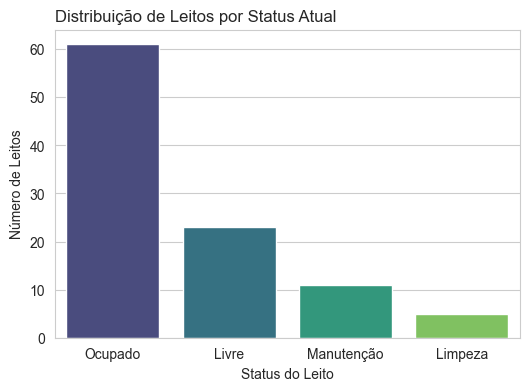

In [73]:
#Criando gráficos

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

#Gráfico 1: Distribuição de Leitos por Status
plt.figure(figsize = (6,4))
sns.countplot(data = df_leitos, x = 'Status', palette = 'viridis', order = df_leitos['Status'].value_counts().index)
plt.title('Distribuição de Leitos por Status Atual', loc = 'left')
plt.xlabel('Status do Leito')
plt.ylabel('Número de Leitos')
plt.show()

C:\Users\vincy\AppData\Local\Temp\ipykernel_26984\1783185298.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df_leitos, x = 'Tipo_Leito', palette = 'magma', order = df_leitos['Tipo_Leito'].value_counts().index)


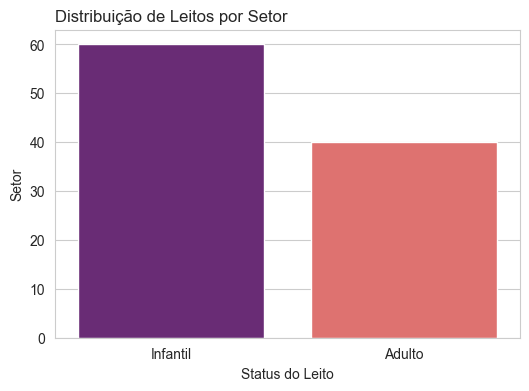

In [72]:
#Gráfico 2: Distribuição de Leitos por Setor
plt.figure(figsize = (6,4))
sns.countplot(data = df_leitos, x = 'Tipo_Leito', palette = 'magma', order = df_leitos['Tipo_Leito'].value_counts().index)
plt.title('Distribuição de Leitos por Setor', loc = 'left')
plt.xlabel('Status do Leito')
plt.ylabel('Setor')
plt.show()

C:\Users\vincy\AppData\Local\Temp\ipykernel_26984\3171680384.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df_ocupados, x = 'Setor', palette = 'rocket', order = df_ocupados['Setor'].value_counts().index)


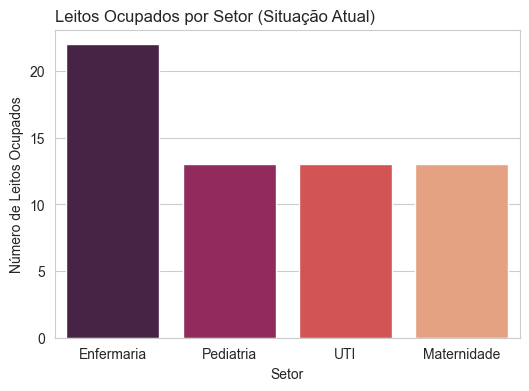

In [78]:
#Gráfico 3: Leitos Ocupados por Setor (Situação Atual)

#gerando um dataframe somente com os leitos que estão como 'ocupados'
df_ocupados = df_leitos[df_leitos['Status'] == 'Ocupado']

plt.figure(figsize = (6,4))
sns.countplot(data = df_ocupados, x = 'Setor', palette = 'rocket', order = df_ocupados['Setor'].value_counts().index)
plt.title('Leitos Ocupados por Setor (Situação Atual)', loc = 'left')
plt.xlabel('Setor')
plt.ylabel('Número de Leitos Ocupados')
plt.show()

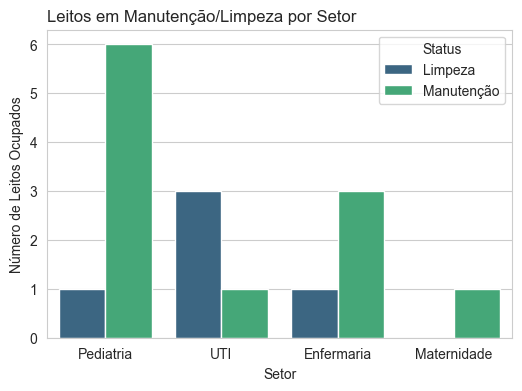

In [82]:
#Gráfico 4: Leitos em Manutenção/Limpeza por Setor

#gerando um dataframe somente com os leitos que estão como 'manutenção' ou 'limpeza'
df_manutencao_limpeza = df_leitos[df_leitos['Status'].isin(['Manutenção', 'Limpeza'])]

plt.figure(figsize = (6,4))
sns.countplot(data = df_manutencao_limpeza, x = 'Setor', hue = 'Status', palette = 'viridis', order = df_manutencao_limpeza['Setor'].value_counts().index)
plt.title('Leitos em Manutenção/Limpeza por Setor', loc = 'left')
plt.xlabel('Setor')
plt.ylabel('Número de Leitos Ocupados')
plt.legend(title = 'Status')
plt.show()

In [83]:
#exportando os dataframes para arquivos em excel

df_leitos.to_excel('Leitos_Tratados_Pandas.xlsx', index = False)
df_pacientes.to_excel('Pacientes_Tratados_Pandas.xlsx', index = False)